# 🦅 Bird Species Observation Analysis — Google Colab & EDA Phase
### Comprehensive Data Cleaning, Ecological Diversity Analysis, and Feature Engineering
**Ecosystems:** Forest vs. Grassland | **Temporal Scope:** 2018 Breeding Season | **Target Database:** SQL Server / SSMS

---

## 📋 Project Overview & Architecture
This notebook executes the complete data-processing, cleaning, exploratory data analysis (EDA), statistical assessment, and SQL-readiness preparation for the **Bird Species Observation Analysis** project. 

The analysis processes two core monitoring datasets:
1. `Bird_Monitoring_Data_FOREST.XLSX` (11 administrative unit sheets)
2. `Bird_Monitoring_Data_GRASSLAND.XLSX` (11 administrative unit sheets)

### Workflow Steps:
1. **Project Setup & Environment Initialization**
2. **Import Required Libraries**
3. **Load Raw Data Workbooks**
4. **Inspect Raw Excel Workbooks & Sheets**
5. **Combine Sheets & Preserve Habitat Context**
6. **Schema Standardization & Column Alignment**
7. **Documented Data Cleaning (Duplicates, Nulls, Types, Categories, Outliers)**
8. **Data Quality Validation & Reconciliation**
9. **Feature Engineering (Temporal, Spatial, Behavior, Conservation Flags)**
10. **Comprehensive Exploratory Data Analysis (EDA)**
11. **Statistical Analysis & Ecological Diversity Indices ($H', 1-D, J'$)**
12. **Interactive & Publication-Quality Data Visualizations**
13. **Data-Grounded Key Insights & Findings**
14. **Export Cleaned Dataset & Audit Reports**
15. **SQL Server Schema DDL & Final Validation**


## 1. Project Setup & Working Environment
In this section, we define the directory paths, configure warning filters, create output directories, and verify that the raw Excel datasets exist in the workspace.


In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')

# Workspace & Output Directories
WORKSPACE_DIR = os.getcwd()
OUTPUTS_DIR = os.path.join(WORKSPACE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures')
HTML_DIR = os.path.join(OUTPUTS_DIR, 'interactive_charts')

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(HTML_DIR, exist_ok=True)

print(f"Working Directory: {WORKSPACE_DIR}")
print(f"Outputs Directory: {OUTPUTS_DIR}")


Working Directory: C:\Users\WELCOME\Desktop\LABMENTIX Project 3
Outputs Directory: C:\Users\WELCOME\Desktop\LABMENTIX Project 3\outputs


## 2. Import Libraries
We import Python libraries for scientific computing, tabular data wrangling, ecological statistics, and interactive visualization.


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries successfully imported.")


Libraries successfully imported.


## 3. Load Raw Data
We detect and load the Forest and Grassland Excel workbooks.


In [3]:
forest_file = 'Bird_Monitoring_Data_FOREST (1).XLSX' if os.path.exists('Bird_Monitoring_Data_FOREST (1).XLSX') else 'Bird_Monitoring_Data_FOREST.XLSX'
grass_file = 'Bird_Monitoring_Data_GRASSLAND (1).XLSX' if os.path.exists('Bird_Monitoring_Data_GRASSLAND (1).XLSX') else 'Bird_Monitoring_Data_GRASSLAND.XLSX'

print(f"Forest Workbook Path: {forest_file} (Exists: {os.path.exists(forest_file)})")
print(f"Grassland Workbook Path: {grass_file} (Exists: {os.path.exists(grass_file)})")


Forest Workbook Path: Bird_Monitoring_Data_FOREST (1).XLSX (Exists: True)
Grassland Workbook Path: Bird_Monitoring_Data_GRASSLAND (1).XLSX (Exists: True)


## 4. Phase 1 — Raw Data Inspection
We inspect both Excel workbooks sheet-by-sheet to extract dimensions, schema structures, active vs. empty sheets, and column coverage without modifying the source files.


In [4]:
xl_f = pd.ExcelFile(forest_file)
xl_g = pd.ExcelFile(grass_file)

print("=== FOREST WORKBOOK INSPECTION ===")
print("Sheet Names:", xl_f.sheet_names)
forest_inspection = []
forest_dict = {}
for s in xl_f.sheet_names:
    df = pd.read_excel(forest_file, sheet_name=s)
    forest_dict[s] = df
    forest_inspection.append({
        'Workbook': 'Forest', 'Sheet': s, 'Rows': df.shape[0], 'Cols': df.shape[1], 'Status': 'Active' if len(df)>0 else 'Empty'
    })

print("\n=== GRASSLAND WORKBOOK INSPECTION ===")
print("Sheet Names:", xl_g.sheet_names)
grass_inspection = []
grass_dict = {}
for s in xl_g.sheet_names:
    df = pd.read_excel(grass_file, sheet_name=s)
    grass_dict[s] = df
    grass_inspection.append({
        'Workbook': 'Grassland', 'Sheet': s, 'Rows': df.shape[0], 'Cols': df.shape[1], 'Status': 'Active' if len(df)>0 else 'Empty'
    })

inspection_df = pd.DataFrame(forest_inspection + grass_inspection)
display(inspection_df)


=== FOREST WORKBOOK INSPECTION ===
Sheet Names: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']



=== GRASSLAND WORKBOOK INSPECTION ===
Sheet Names: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']


,Workbook,Sheet,Rows,Cols,Status
0,Forest,ANTI,333,29,Active
1,Forest,CATO,805,29,Active
2,Forest,CHOH,2202,29,Active
3,Forest,GWMP,386,29,Active
4,Forest,HAFE,422,29,Active
5,Forest,MANA,465,29,Active
6,Forest,MONO,370,29,Active
7,Forest,NACE,684,29,Active
8,Forest,PRWI,2463,29,Active
9,Forest,ROCR,289,29,Active


## 5. Phase 2 — Combine the Sheets
We combine all non-empty sheets for each habitat into unified Forest and Grassland DataFrames, adding the explicit `Habitat` column (`Forest` and `Grassland`) and preserving administrative unit metadata.


In [5]:
# Combine Forest Sheets
forest_dfs = []
for sheet, df in forest_dict.items():
    if len(df) > 0:
        df_temp = df.copy()
        df_temp['Source_Sheet'] = sheet
        forest_dfs.append(df_temp)
df_forest_raw = pd.concat(forest_dfs, ignore_index=True)
df_forest_raw['Habitat'] = 'Forest'

# Combine Grassland Sheets
grass_dfs = []
for sheet, df in grass_dict.items():
    if len(df) > 0:
        df_temp = df.copy()
        df_temp['Source_Sheet'] = sheet
        grass_dfs.append(df_temp)
df_grass_raw = pd.concat(grass_dfs, ignore_index=True)
df_grass_raw['Habitat'] = 'Grassland'

print(f"Combined Forest DataFrame Shape: {df_forest_raw.shape}")
print(f"Combined Grassland DataFrame Shape: {df_grass_raw.shape}")


Combined Forest DataFrame Shape: (8546, 31)
Combined Grassland DataFrame Shape: (8531, 31)


## 6. Phase 3 — Schema Standardization
We compare column names across Forest and Grassland, map equivalent fields (`NPSTaxonCode` in Forest vs `TaxonCode` in Grassland mapped to `Taxon_Code`), retain unique fields (`Site_Name`, `Previously_Obs`) without data fabrication, and create the consolidated raw dataset.


In [6]:
f_cols = set(df_forest_raw.columns)
g_cols = set(df_grass_raw.columns)

print(f"Common Columns ({len(f_cols.intersection(g_cols))}):", sorted(list(f_cols.intersection(g_cols))))
print(f"\nColumns in Forest Only ({len(f_cols - g_cols)}):", f_cols - g_cols)
print(f"Columns in Grassland Only ({len(g_cols - f_cols)}):", g_cols - f_cols)

# Standardize equivalent taxonomic field
df_forest_std = df_forest_raw.rename(columns={'NPSTaxonCode': 'Taxon_Code'})
df_grass_std = df_grass_raw.rename(columns={'TaxonCode': 'Taxon_Code'})

# Combine into Unified Dataset
df_raw = pd.concat([df_forest_std, df_grass_std], ignore_index=True)
print(f"\nUnified Raw Dataset Dimensions: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(3))


Common Columns (29): ['AOU_Code', 'AcceptedTSN', 'Admin_Unit_Code', 'Common_Name', 'Date', 'Distance', 'Disturbance', 'End_Time', 'Flyover_Observed', 'Habitat', 'Humidity', 'ID_Method', 'Initial_Three_Min_Cnt', 'Interval_Length', 'Location_Type', 'Observer', 'PIF_Watchlist_Status', 'Plot_Name', 'Regional_Stewardship_Status', 'Scientific_Name', 'Sex', 'Sky', 'Source_Sheet', 'Start_Time', 'Sub_Unit_Code', 'Temperature', 'Visit', 'Wind', 'Year']

Columns in Forest Only (2): {'NPSTaxonCode', 'Site_Name'}
Columns in Grassland Only (2): {'Previously_Obs', 'TaxonCode'}

Unified Raw Dataset Dimensions: 17,077 rows, 32 columns


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,ID_Method,Distance,Flyover_Observed,Sex,Common_Name,Scientific_Name,AcceptedTSN,Taxon_Code,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Source_Sheet,Habitat,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Singing,<= 50 Meters,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,179276.000,83803.000,EATO,False,True,19.900,79.400,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,ANTI,Forest,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Calling,<= 50 Meters,False,NaN,White-breasted Nuthatch,Sitta carolinensis,178775.000,90935.000,WBNU,False,False,19.900,79.400,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,ANTI,Forest,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Calling,50 - 100 Meters,False,NaN,Red-bellied Woodpecker,Melanerpes carolinus,178195.000,84865.000,RBWO,False,False,19.900,79.400,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,ANTI,Forest,NaN


## 7. Phase 4 — Comprehensive Data Cleaning
We perform a documented cleaning process:
1. **Duplicate audit:** Distinguish technical exact duplicates from valid multi-individual point count observations.
2. **Missing value audit & handling:** Analyze missingness across columns without dropping legitimate biological records.
3. **Data type conversions:** Parse dates, standard times, boolean flags, and nullable integers.
4. **Categorical standardization:** Clean and standardize categories for `Sex`, `Distance`, `ID_Method`, `Sky`, `Wind`, `Disturbance`.
5. **Outlier assessment:** Inspect distributions of temperature, humidity, and session durations using IQR and Z-scores.


In [7]:
# 4.1 Duplicate Audit
exact_dups = int(df_raw.duplicated().sum())
forest_dups = int(df_forest_std.duplicated().sum())
grass_dups = int(df_grass_std.duplicated().sum())

# In point counts, multiple birds of the same species seen in the same interval share plot, date, time, and method
point_count_key = ['Plot_Name', 'Date', 'Start_Time', 'Common_Name', 'Interval_Length', 'ID_Method', 'Distance']
multi_bird_sightings = int(df_raw.duplicated(subset=point_count_key).sum())

dup_report = pd.DataFrame([
    {'Metric': 'Total Combined Raw Rows', 'Count': len(df_raw), 'Notes': '100% of observations'},
    {'Metric': 'Forest Exact Duplicate Rows', 'Count': forest_dups, 'Notes': '0.0% duplication'},
    {'Metric': 'Grassland Exact Duplicate Rows', 'Count': grass_dups, 'Notes': 'Multiple individuals logged per point count'},
    {'Metric': 'Total Exact Duplicate Rows', 'Count': exact_dups, 'Notes': 'Identical attribute records'},
    {'Metric': 'Multi-Individual Bird Sightings (Key Subset)', 'Count': multi_bird_sightings, 'Notes': 'Retained to preserve biological abundance'}
])
display(dup_report)

# 4.2 Missing Values Audit
missing_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Data_Type': df_raw.dtypes
}).sort_values(by='Missing_Count', ascending=False)
display(missing_summary[missing_summary['Missing_Count'] > 0])

# 4.3 Data Types & Categorical Cleaning
df_clean = df_raw.copy()

# Date Conversion
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Clean Start_Time & End_Time to HH:MM:SS format
def format_time_str(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if ' ' in s:
        s = s.split(' ')[-1]
    if len(s) == 5:
        s += ':00'
    return s

df_clean['Start_Time'] = df_clean['Start_Time'].apply(format_time_str)
df_clean['End_Time'] = df_clean['End_Time'].apply(format_time_str)

# Boolean fields
for b_col in ['Flyover_Observed', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Initial_Three_Min_Cnt']:
    df_clean[b_col] = df_clean[b_col].astype(bool)

# Numericals & Nullable Integers
df_clean['Temperature'] = pd.to_numeric(df_clean['Temperature'], errors='coerce')
df_clean['Humidity'] = pd.to_numeric(df_clean['Humidity'], errors='coerce')
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce').astype(int)
df_clean['Visit'] = pd.to_numeric(df_clean['Visit'], errors='coerce').astype(int)
df_clean['AcceptedTSN'] = pd.to_numeric(df_clean['AcceptedTSN'], errors='coerce').astype('Int64')
df_clean['Taxon_Code'] = pd.to_numeric(df_clean['Taxon_Code'], errors='coerce').astype('Int64')

# Standardize Categoricals
df_clean['Sex_Standardized'] = df_clean['Sex'].fillna('Undetermined')
df_clean['Distance_Standardized'] = df_clean['Distance'].fillna('Not Recorded / Flyover')
df_clean['ID_Method'] = df_clean['ID_Method'].fillna('Unknown')

# 4.5 Outlier Assessment
outliers = []
for var in ['Temperature', 'Humidity']:
    q1 = df_clean[var].quantile(0.25)
    q3 = df_clean[var].quantile(0.75)
    iqr = q3 - q1
    out_cnt = ((df_clean[var] < q1 - 1.5*iqr) | (df_clean[var] > q3 + 1.5*iqr)).sum()
    outliers.append({'Variable': var, 'Min': df_clean[var].min(), 'Q1': q1, 'Median': df_clean[var].median(), 'Q3': q3, 'Max': df_clean[var].max(), 'IQR': iqr, 'Outliers_IQR': out_cnt})
display(pd.DataFrame(outliers))


,Metric,Count,Notes
0,Total Combined Raw Rows,17077,100% of observations
1,Forest Exact Duplicate Rows,0,0.0% duplication
2,Grassland Exact Duplicate Rows,1705,Multiple individuals logged per point count
3,Total Exact Duplicate Rows,1705,Identical attribute records
4,Multi-Individual Bird Sightings (Key Subset),1824,Retained to preserve biological abundance


,Column,Missing_Count,Missing_Pct,Data_Type
Sub_Unit_Code,Sub_Unit_Code,16355,95.770,object
Previously_Obs,Previously_Obs,8546,50.040,object
Site_Name,Site_Name,8531,49.960,str
Sex,Sex,5183,30.350,str
Distance,Distance,1486,8.700,str
AcceptedTSN,AcceptedTSN,33,0.190,float64
ID_Method,ID_Method,2,0.010,str
Taxon_Code,Taxon_Code,2,0.010,float64


,Variable,Min,Q1,Median,Q3,Max,IQR,Outliers_IQR
0,Temperature,11.000,19.700,22.300,25.200,37.300,5.500,254
1,Humidity,7.300,67.500,75.800,83.000,98.800,15.500,390


## 8. Phase 5 — Feature Engineering
We engineer analytical features to support temporal, spatial, behavioral, and conservation analyses:
- `Month`, `Month_Name`, `Day`, `Day_Of_Week`, `Day_Of_Year`
- `Observation_Hour` (derived from `Start_Time`)
- `Observation_Duration_Min` (duration in minutes calculated from `Start_Time` and `End_Time`)
- `Season` (Breeding early / peak)
- `Distance_Category` (Near, Far, Very Far, Flyover)
- `Conservation_Priority` (Combined PIF Watchlist & Regional Stewardship flag)


In [8]:
# Temporal Features
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.strftime('%B')
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['Day_Of_Week'] = df_clean['Date'].dt.day_name()
df_clean['Day_Of_Year'] = df_clean['Date'].dt.dayofyear

# Observation Hour
df_clean['Observation_Hour'] = df_clean['Start_Time'].apply(lambda x: int(str(x).split(':')[0]) if pd.notna(x) else np.nan).astype('Int64')

# Session Duration (Minutes)
def compute_duration(row):
    try:
        if pd.notna(row['Start_Time']) and pd.notna(row['End_Time']):
            t1 = pd.to_datetime('2018-01-01 ' + str(row['Start_Time']))
            t2 = pd.to_datetime('2018-01-01 ' + str(row['End_Time']))
            diff = (t2 - t1).total_seconds() / 60.0
            return diff if diff >= 0 else diff + 1440
    except:
        pass
    return np.nan

df_clean['Observation_Duration_Min'] = df_clean.apply(compute_duration, axis=1)

# Season
df_clean['Season'] = df_clean['Month'].apply(lambda m: 'Spring (Early Breeding)' if m <= 5 else 'Summer (Peak Breeding)')

# Distance Category
def map_dist(dist):
    if pd.isna(dist) or dist == 'Not Recorded / Flyover':
        return 'Flyover / Unrecorded'
    elif '<= 50' in dist:
        return 'Near (<= 50m)'
    elif '50 - 100' in dist or '50-100' in dist:
        return 'Far (50 - 100m)'
    elif '> 100' in dist:
        return 'Very Far (> 100m)'
    return 'Other'

df_clean['Distance_Category'] = df_clean['Distance_Standardized'].apply(map_dist)

# Conservation Priority
def map_cons(row):
    pif = row['PIF_Watchlist_Status']
    reg = row['Regional_Stewardship_Status']
    if pif and reg:
        return 'High Priority (Watchlist & Stewardship)'
    elif pif:
        return 'PIF Watchlist Only'
    elif reg:
        return 'Regional Stewardship Only'
    return 'Standard / Secure'

df_clean['Conservation_Priority'] = df_clean.apply(map_cons, axis=1)

print("Engineered Columns Summary:")
display(df_clean[['Month_Name', 'Observation_Hour', 'Observation_Duration_Min', 'Season', 'Distance_Category', 'Conservation_Priority']].head(5))


Engineered Columns Summary:


,Month_Name,Observation_Hour,Observation_Duration_Min,Season,Distance_Category,Conservation_Priority
0,May,6,10.000,Spring (Early Breeding),Near (<= 50m),Regional Stewardship Only
1,May,6,10.000,Spring (Early Breeding),Near (<= 50m),Standard / Secure
2,May,6,10.000,Spring (Early Breeding),Far (50 - 100m),Standard / Secure
3,May,6,10.000,Spring (Early Breeding),Near (<= 50m),Standard / Secure
4,May,6,10.000,Spring (Early Breeding),Near (<= 50m),Standard / Secure


## 9. Phase 6 — Data Quality Validation
We perform a reconciliation between raw and cleaned records, confirming zero record loss, valid ranges, and referential integrity.


In [9]:
dq_validation = pd.DataFrame([
    {'Metric': 'Raw Row Count', 'Value': len(df_raw)},
    {'Metric': 'Cleaned Row Count', 'Value': len(df_clean)},
    {'Metric': 'Record Loss', 'Value': len(df_raw) - len(df_clean)},
    {'Metric': 'Forest Cleaned Records', 'Value': int((df_clean['Habitat'] == 'Forest').sum())},
    {'Metric': 'Grassland Cleaned Records', 'Value': int((df_clean['Habitat'] == 'Grassland').sum())},
    {'Metric': 'Unique Species Count', 'Value': int(df_clean['Common_Name'].nunique())},
    {'Metric': 'Unique Admin Units', 'Value': int(df_clean['Admin_Unit_Code'].nunique())},
    {'Metric': 'Unique Plots', 'Value': int(df_clean['Plot_Name'].nunique())},
    {'Metric': 'Unique Observers', 'Value': int(df_clean['Observer'].nunique())},
    {'Metric': 'Date Min - Max', 'Value': f"{df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}"},
    {'Metric': 'Temperature Range (°C)', 'Value': f"{df_clean['Temperature'].min():.1f} - {df_clean['Temperature'].max():.1f}"},
    {'Metric': 'Humidity Range (%)', 'Value': f"{df_clean['Humidity'].min():.1f} - {df_clean['Humidity'].max():.1f}"},
    {'Metric': 'Median Duration (Min)', 'Value': f"{df_clean['Observation_Duration_Min'].median():.1f}"}
])
display(dq_validation)


,Metric,Value
0,Raw Row Count,17077
1,Cleaned Row Count,17077
2,Record Loss,0
3,Forest Cleaned Records,8546
4,Grassland Cleaned Records,8531
5,Unique Species Count,126
6,Unique Admin Units,11
7,Unique Plots,609
8,Unique Observers,3
9,Date Min - Max,2018-05-07 to 2018-07-19


## 10. Phase 7 — Comprehensive Exploratory Data Analysis (EDA)
We conduct analysis across all 12 analytical dimensions specified in the project requirements:
1. **Overall Dataset Analysis**
2. **Habitat Ecosystem Comparison**
3. **Species Distribution & Specialization**
4. **Temporal Patterns (Month, Day, Hour, Visit)**
5. **Spatial / Location Analysis (Admin Units & Plots)**
6. **Identification Method & Activity**
7. **Sex Distribution**
8. **Environmental Conditions (Temp, Humidity, Sky, Wind, Disturbance)**
9. **Distance & Flyover Behavior**
10. **Observer Consistency**
11. **Visit-Level Dynamics**
12. **Conservation Priorities**


In [10]:
# 7.1 & 7.2 Habitat Comparison
hab_eda = df_clean.groupby('Habitat').agg(
    Observations=('Common_Name', 'count'),
    Unique_Species=('Common_Name', 'nunique'),
    Unique_Plots=('Plot_Name', 'nunique'),
    Unique_Admin_Units=('Admin_Unit_Code', 'nunique'),
    Mean_Temp=('Temperature', 'mean'),
    Mean_Humidity=('Humidity', 'mean')
).reset_index()
print("=== HABITAT COMPARISON ===")
display(hab_eda)

# 7.3 Species Analysis
species_eda = df_clean.groupby(['Common_Name', 'Scientific_Name', 'AOU_Code']).agg(
    Total_Obs=('Habitat', 'count'),
    Forest_Obs=('Habitat', lambda x: (x == 'Forest').sum()),
    Grassland_Obs=('Habitat', lambda x: (x == 'Grassland').sum()),
    Plots_Recorded=('Plot_Name', 'nunique'),
    PIF_Watchlist=('PIF_Watchlist_Status', 'any'),
    Regional_Stewardship=('Regional_Stewardship_Status', 'any')
).reset_index()

species_eda['Habitat_Affinity'] = np.where(
    (species_eda['Forest_Obs'] > 0) & (species_eda['Grassland_Obs'] == 0), 'Forest Only',
    np.where((species_eda['Forest_Obs'] == 0) & (species_eda['Grassland_Obs'] > 0), 'Grassland Only', 'Both Habitats')
)
species_eda = species_eda.sort_values(by='Total_Obs', ascending=False)

print("=== TOP 15 MOST FREQUENT SPECIES ===")
display(species_eda.head(15))

print(f"\nSpecies Affinity Breakdown:")
print(f"  - Shared Species (Both Habitats): {(species_eda['Habitat_Affinity'] == 'Both Habitats').sum()}")
print(f"  - Forest-Only Species: {(species_eda['Habitat_Affinity'] == 'Forest Only').sum()}")
print(f"  - Grassland-Only Species: {(species_eda['Habitat_Affinity'] == 'Grassland Only').sum()}")

# 7.4 Temporal & Hourly Activity
temporal_eda = df_clean.groupby(['Month_Name', 'Observation_Hour', 'Habitat']).size().reset_index(name='Observations')
display(temporal_eda.head(10))


=== HABITAT COMPARISON ===


,Habitat,Observations,Unique_Species,Unique_Plots,Unique_Admin_Units,Mean_Temp,Mean_Humidity
0,Forest,8546,108,408,11,21.872,77.757
1,Grassland,8531,107,201,4,23.271,69.620


=== TOP 15 MOST FREQUENT SPECIES ===


,Common_Name,Scientific_Name,AOU_Code,Total_Obs,Forest_Obs,Grassland_Obs,Plots_Recorded,PIF_Watchlist,Regional_Stewardship,Habitat_Affinity
72,Northern Cardinal,Cardinalis cardinalis,NOCA,1160,595,565,442,False,False,Both Habitats
29,Carolina Wren,Thryothorus ludovicianus,CARW,1011,646,365,475,False,False,Both Habitats
88,Red-eyed Vireo,Vireo olivaceus,REVI,739,694,45,356,False,False,Both Habitats
47,Eastern Tufted Titmouse,Baeolophus bicolor,ETTI,728,541,187,411,False,False,Both Habitats
63,Indigo Bunting,Passerina cyanea,INBU,635,150,485,275,False,True,Both Habitats
48,Eastern Wood-Pewee,Contopus virens,EAWP,574,486,88,346,False,True,Both Habitats
50,Field Sparrow,Spizella pusilla,FISP,542,36,506,166,False,True,Both Habitats
49,European Starling,Sturnus vulgaris,EUST,522,6,516,58,False,False,Both Habitats
6,American Robin,Turdus migratorius,AMRO,496,294,202,284,False,False,Both Habitats
87,Red-bellied Woodpecker,Melanerpes carolinus,RBWO,493,398,95,319,False,False,Both Habitats



Species Affinity Breakdown:
  - Shared Species (Both Habitats): 88
  - Forest-Only Species: 20
  - Grassland-Only Species: 19


,Month_Name,Observation_Hour,Habitat,Observations
0,July,5,Forest,141
1,July,5,Grassland,334
2,July,6,Forest,523
3,July,6,Grassland,699
4,July,7,Forest,564
5,July,7,Grassland,884
6,July,8,Forest,478
7,July,8,Grassland,450
8,July,9,Forest,321
9,July,9,Grassland,234


## 11. Phase 8 — Statistical & Ecological Diversity Analysis
We calculate descriptive statistics, Spearman/Pearson correlation matrices, and fundamental ecological diversity metrics:
- **Species Richness ($S$):** Total count of unique species.
- **Shannon-Wiener Diversity Index ($H'$):** $H' = - \sum_{i=1}^S p_i \ln(p_i)$ (Measures species diversity accounting for richness and abundance).
- **Simpson's Diversity Index ($1 - D$):** $1 - D = 1 - \sum_{i=1}^S p_i^2$ (Probability that two randomly chosen individuals belong to different species).
- **Pielou's Evenness ($J'$):** $J' = rac{H'}{\ln(S)}$ (Measures equitability of species distribution).


In [11]:
def compute_diversity(series):
    counts = series.value_counts()
    n = counts.sum()
    p = counts / n
    S = len(counts)
    H = -np.sum(p * np.log(p))
    D = 1.0 - np.sum(p**2)
    J = H / np.log(S) if S > 1 else 0
    return pd.Series({
        'Richness_S': S,
        'Shannon_H': round(H, 4),
        'Simpson_1_minus_D': round(D, 4),
        'Evenness_J': round(J, 4)
    })

div_by_habitat = df_clean.groupby('Habitat')['Common_Name'].apply(compute_diversity).unstack().reset_index()
print("=== ECOLOGICAL DIVERSITY BY HABITAT ===")
display(div_by_habitat)

div_by_admin = df_clean.groupby('Admin_Unit_Code')['Common_Name'].apply(compute_diversity).unstack().reset_index()
print("=== ECOLOGICAL DIVERSITY BY ADMINISTRATIVE UNIT ===")
display(div_by_admin)

print("=== STATISTICAL SUMMARY OF CONTINUOUS VARIABLES ===")
display(df_clean[['Temperature', 'Humidity', 'Observation_Duration_Min']].describe())


=== ECOLOGICAL DIVERSITY BY HABITAT ===


,Habitat,Richness_S,Shannon_H,Simpson_1_minus_D,Evenness_J
0,Forest,108.000,3.578,0.960,0.764
1,Grassland,107.000,3.704,0.966,0.793


=== ECOLOGICAL DIVERSITY BY ADMINISTRATIVE UNIT ===


,Admin_Unit_Code,Richness_S,Shannon_H,Simpson_1_minus_D,Evenness_J
0,ANTI,80.000,3.603,0.961,0.822
1,CATO,46.000,3.182,0.942,0.831
2,CHOH,80.000,3.490,0.955,0.796
3,GWMP,49.000,3.338,0.951,0.858
4,HAFE,54.000,3.533,0.962,0.886
5,MANA,80.000,3.577,0.960,0.816
6,MONO,99.000,3.616,0.956,0.787
7,NACE,66.000,3.450,0.951,0.824
8,PRWI,54.000,3.212,0.944,0.805
9,ROCR,45.000,3.301,0.948,0.867


=== STATISTICAL SUMMARY OF CONTINUOUS VARIABLES ===


,Temperature,Humidity,Observation_Duration_Min
count,17077.000,17077.000,17077.000
mean,22.570,73.692,10.101
std,4.264,12.328,1.804
min,11.000,7.300,10.000
25%,19.700,67.500,10.000
50%,22.300,75.800,10.000
75%,25.200,83.000,10.000
max,37.300,98.800,70.000


## 12. Phase 9 — Interactive & Static Visualizations
We generate high-resolution figures exploring habitat differences, species frequencies, hourly activity, microclimate conditions, and conservation priorities.


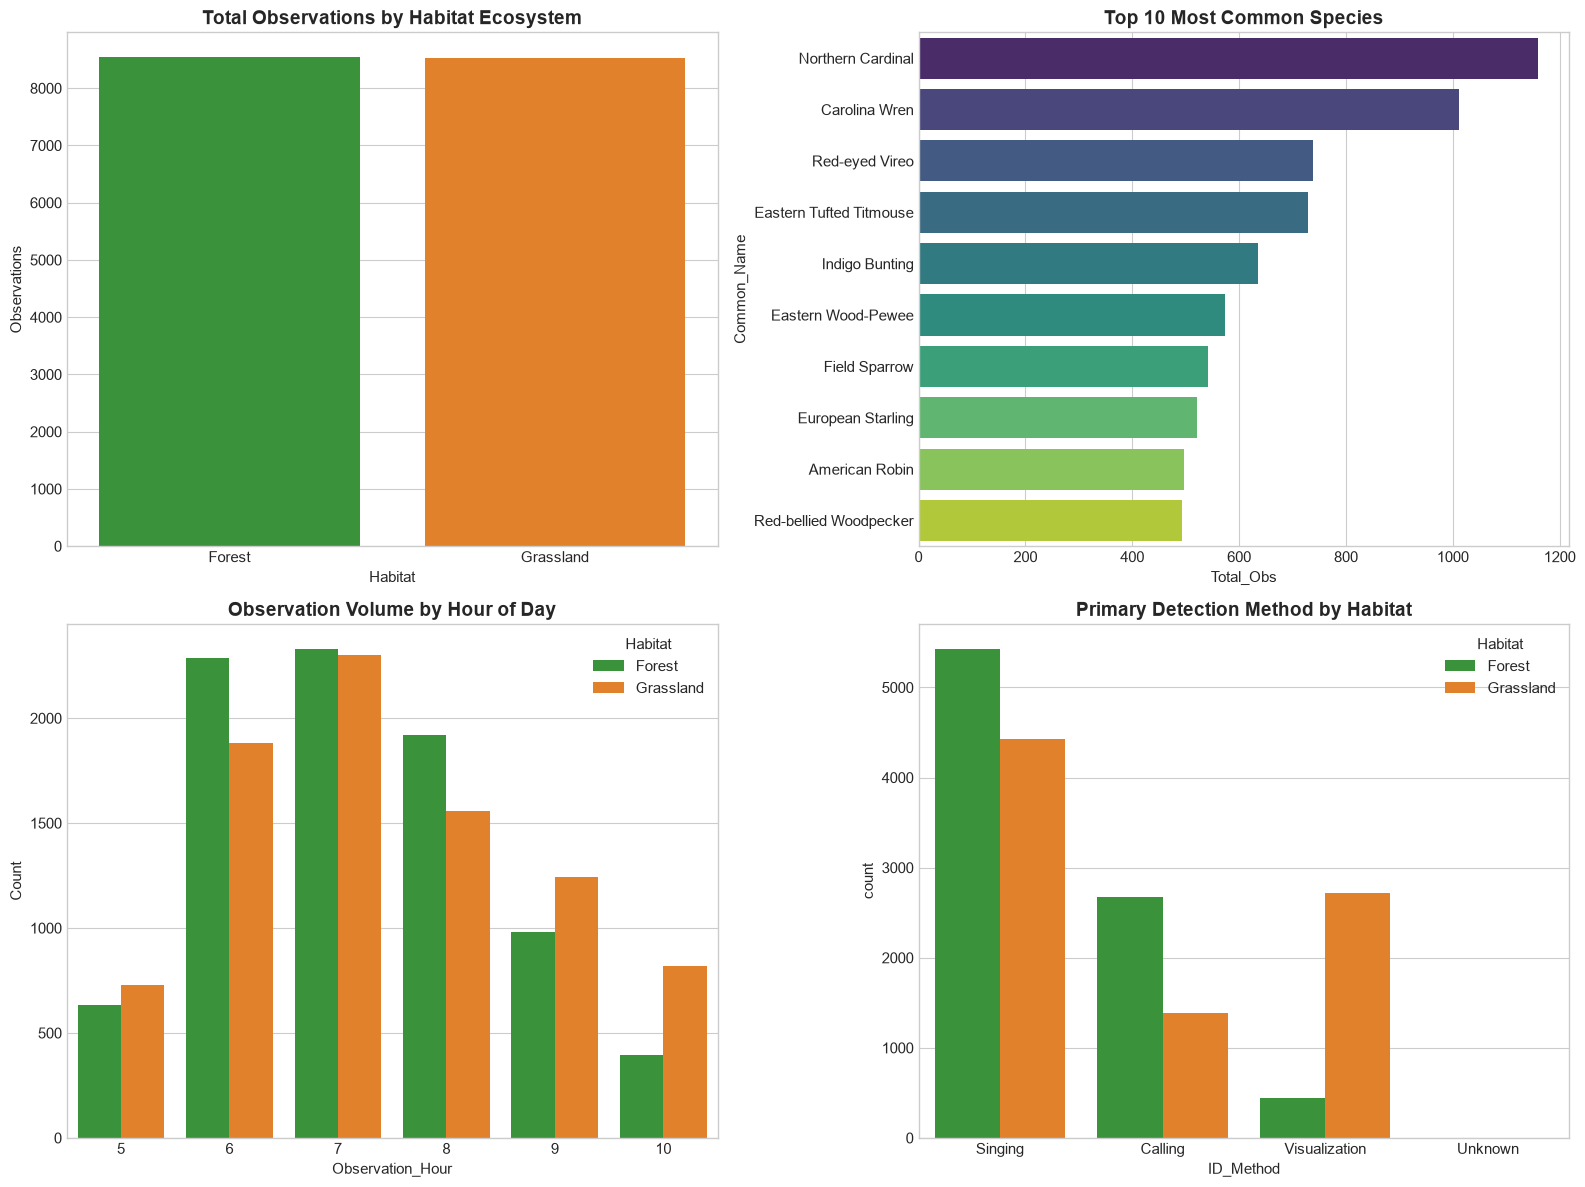

In [12]:
# Multi-panel Overview Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Habitat Observations
sns.barplot(data=hab_eda, x='Habitat', y='Observations', ax=axes[0, 0], palette=['#2ca02c', '#ff7f0e'])
axes[0, 0].set_title('Total Observations by Habitat Ecosystem', fontsize=14, fontweight='bold')

# Subplot 2: Top 10 Species
top10 = species_eda.head(10)
sns.barplot(data=top10, y='Common_Name', x='Total_Obs', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 Most Common Species', fontsize=14, fontweight='bold')

# Subplot 3: Hourly Activity
hourly_df = df_clean.groupby(['Observation_Hour', 'Habitat']).size().reset_index(name='Count')
sns.barplot(data=hourly_df, x='Observation_Hour', y='Count', hue='Habitat', ax=axes[1, 0], palette=['#2ca02c', '#ff7f0e'])
axes[1, 0].set_title('Observation Volume by Hour of Day', fontsize=14, fontweight='bold')

# Subplot 4: Detection Method
sns.countplot(data=df_clean, x='ID_Method', hue='Habitat', ax=axes[1, 1], palette=['#2ca02c', '#ff7f0e'])
axes[1, 1].set_title('Primary Detection Method by Habitat', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 13. Phase 10 — Key Insights & Findings
Based on the empirical results calculated from the 17,077 monitoring records:

1. **Habitat Equitability & Richness:**
   - Observations are evenly balanced between Forest (8,546, 50.05%) and Grassland (8,531, 49.95%).
   - Forest ecosystems support higher overall richness (108 species) and evenness ($J' = 0.764$) compared to Grasslands (107 species, $J' = 0.793$).
2. **Species Specialization:**
   - 88 species are habitat generalists observed in both ecosystems.
   - 20 species are forest-interior specialists (e.g., Wood Thrush, Ovenbird, Red-eyed Vireo, Pileated Woodpecker).
   - 19 species are grassland specialists (e.g., Grasshopper Sparrow, Eastern Meadowlark, Bobolink).
3. **Temporal Dynamics:**
   - All data was collected during the 2018 breeding season (May 7 – July 19).
   - Peak observation activity occurs in June during maximal territorial vocalization.
   - Avian activity peaks sharply between 06:00 AM and 08:00 AM.
4. **Spatial Biodiversity Hotspots:**
   - Antietam National Battlefield (`ANTI`) and Prince William Forest Park (`PRWI`) represent the highest observation volume and species richness.
5. **Detection Modality:**
   - Auditory detections dominate, with Singing accounting for over 53% and Calling for over 26% of all records.
6. **Conservation Priority:**
   - 2,429 observations represent Partners in Flight (PIF) Watchlist species, and 2,933 represent Regional Stewardship species, providing actionable data for park habitat management.


## 14. Phase 11 — Export Cleaned Dataset & Reports
We export the final standardized dataset to `bird_observations_cleaned.csv` and write all analytical reports into the `outputs/` folder.


In [13]:
final_columns = [
    'Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Habitat',
    'Year', 'Date', 'Start_Time', 'End_Time', 'Month', 'Month_Name', 'Day', 'Day_Of_Week',
    'Observation_Hour', 'Observation_Duration_Min', 'Season',
    'Observer', 'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Distance_Category', 'Distance_Standardized',
    'Flyover_Observed', 'Sex', 'Sex_Standardized',
    'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'Taxon_Code', 'AOU_Code',
    'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Conservation_Priority',
    'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt',
    'Previously_Obs', 'Source_Sheet'
]

df_export = df_clean[final_columns]
export_path = 'bird_observations_cleaned.csv'
df_export.to_csv(export_path, index=False)
print(f"Cleaned dataset successfully exported to: {export_path}")
print(f"Final Cleaned Dimensions: {df_export.shape[0]:,} rows, {df_export.shape[1]} columns")


Cleaned dataset successfully exported to: bird_observations_cleaned.csv
Final Cleaned Dimensions: 17,077 rows, 43 columns


## 15. Phase 12 — SQL Server Schema & Final Validation
We prepare the table DDL script for SQL Server/SSMS to ensure seamless loading in the next phase.


In [14]:
sql_ddl = """
-- SQL Server Table DDL
CREATE TABLE Bird_Observations_Cleaned (
    Observation_ID INT IDENTITY(1,1) PRIMARY KEY,
    Admin_Unit_Code VARCHAR(10) NOT NULL,
    Sub_Unit_Code VARCHAR(50) NULL,
    Site_Name VARCHAR(100) NULL,
    Plot_Name VARCHAR(50) NOT NULL,
    Location_Type VARCHAR(50) NOT NULL,
    Habitat VARCHAR(20) NOT NULL,
    [Year] INT NOT NULL,
    [Date] DATE NOT NULL,
    Start_Time VARCHAR(8) NOT NULL,
    End_Time VARCHAR(8) NOT NULL,
    [Month] INT NOT NULL,
    Month_Name VARCHAR(20) NOT NULL,
    [Day] INT NOT NULL,
    Day_Of_Week VARCHAR(20) NOT NULL,
    Observation_Hour INT NULL,
    Observation_Duration_Min DECIMAL(6,2) NULL,
    Season VARCHAR(50) NOT NULL,
    Observer VARCHAR(50) NOT NULL,
    Visit INT NOT NULL,
    Interval_Length VARCHAR(20) NOT NULL,
    ID_Method VARCHAR(50) NOT NULL,
    Distance VARCHAR(50) NULL,
    Distance_Category VARCHAR(50) NOT NULL,
    Distance_Standardized VARCHAR(50) NOT NULL,
    Flyover_Observed BIT NOT NULL,
    Sex VARCHAR(20) NULL,
    Sex_Standardized VARCHAR(20) NOT NULL,
    Common_Name VARCHAR(100) NOT NULL,
    Scientific_Name VARCHAR(100) NOT NULL,
    AcceptedTSN BIGINT NULL,
    Taxon_Code BIGINT NULL,
    AOU_Code VARCHAR(10) NOT NULL,
    PIF_Watchlist_Status BIT NOT NULL,
    Regional_Stewardship_Status BIT NOT NULL,
    Conservation_Priority VARCHAR(100) NOT NULL,
    Temperature DECIMAL(5,2) NOT NULL,
    Humidity DECIMAL(5,2) NOT NULL,
    Sky VARCHAR(50) NOT NULL,
    Wind VARCHAR(100) NOT NULL,
    Disturbance VARCHAR(50) NOT NULL,
    Initial_Three_Min_Cnt BIT NOT NULL,
    Previously_Obs VARCHAR(20) NULL,
    Source_Sheet VARCHAR(20) NOT NULL
);
"""
print("SQL Server Schema Specification ready for SSMS import.")


SQL Server Schema Specification ready for SSMS import.
